In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import sqlite3

In [4]:
raw = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_1_blues_blups_comparison/ciat_gas_for_shiny_app_and_blues.csv')
blues = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_1_blues_blups_comparison/blues.csv')
blups = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_1_blues_blups_comparison/blups.csv')

In [5]:
raw.columns

Index(['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange', 'net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'gas_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm'],
      dtype='object')

In [7]:
#Columns processing

category_columns = ['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange']
numeric_columns = ['net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'gas_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm']

for df in [raw]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

In [23]:
means = raw.groupby('id_lab', as_index=False)[numeric_columns].mean().round(2)

/tmp/ipykernel_36522/1312434282.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = raw.groupby('id_lab', as_index=False)[numeric_columns].mean().round(2)


In [25]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
means.to_sql('means', conn_new, if_exists='replace', index=False)
blues.to_sql('blues', conn_new, if_exists='replace', index=False)
blups.to_sql('blups', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [26]:
means.columns

Index(['id_lab', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml', 'ch4_24h_ml',
       'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'gas_ml_g_dm_incubated_24h', 'ch4_ml_g_ndf_digested_24h',
       'methane_intensity', 'tddm'],
      dtype='object')

In [18]:
blues.columns

Index(['id_lab', 'net_gas_8h_ml', 'net_gas_8h_ml_SE', 'net_gas_24h_ml',
       'net_gas_24h_ml_SE', 'ch4_8h_ml', 'ch4_8h_ml_SE', 'ch4_24h_ml',
       'ch4_24h_ml_SE', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_8h_SE', 'ch4_percentage_in_gas_24h',
       'ch4_percentage_in_gas_24h_SE', 'gas_ml_g_dm_incubated_24h',
       'gas_ml_g_dm_incubated_24h_SE', 'ch4_ml_g_ndf_digested_24h',
       'ch4_ml_g_ndf_digested_24h_SE', 'methane_intensity',
       'methane_intensity_SE', 'tddm', 'tddm_SE'],
      dtype='object')

In [19]:
blups.columns

Index(['id_lab', 'net_gas_8h_ml', 'net_gas_8h_ml_SE', 'net_gas_24h_ml',
       'net_gas_24h_ml_SE', 'ch4_8h_ml', 'ch4_8h_ml_SE', 'ch4_24h_ml',
       'ch4_24h_ml_SE', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_8h_SE', 'ch4_percentage_in_gas_24h',
       'ch4_percentage_in_gas_24h_SE', 'gas_ml_g_dm_incubated_24h',
       'gas_ml_g_dm_incubated_24h_SE', 'ch4_ml_g_ndf_digested_24h',
       'ch4_ml_g_ndf_digested_24h_SE', 'methane_intensity',
       'methane_intensity_SE', 'tddm', 'tddm_SE'],
      dtype='object')

In [27]:
query_combined = """
SELECT
      m.id_lab,
      m.ch4_8h_ml as mean_ch4_8h_ml,
      b.ch4_8h_ml as blues_ch4_8h_ml,
      bp.ch4_8h_ml as blups_ch4_8h_ml,
      m.ch4_24h_ml as mean_ch4_24h_ml,
      b.ch4_24h_ml as blues_ch4_24h_ml,
      bp.ch4_24h_ml as blups_ch4_24h_ml,
      m.methane_intensity as mean_methane_intensity,
      b.methane_intensity as blues_methane_intensity,
      bp.methane_intensity as blups_methane_intensity,
      m.tddm as mean_tddm,
      b.tddm as blues_tddm,
      bp.tddm as blups_tddm

FROM means AS m
JOIN blues AS b ON m.id_lab = b.id_lab
JOIN blups AS bp ON m.id_lab = bp.id_lab
"""

comparison  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(comparison)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,id_lab,mean_ch4_8h_ml,blues_ch4_8h_ml,blups_ch4_8h_ml,mean_ch4_24h_ml,blues_ch4_24h_ml,blups_ch4_24h_ml,mean_methane_intensity,blues_methane_intensity,blups_methane_intensity,mean_tddm,blues_tddm,blups_tddm
0,F25-0008,3.03,3.032050,3.041948,8.51,8.508112,8.556730,82.15,95.405716,97.219659,32.06,30.686203,30.222276
1,F25-2077,4.97,4.751345,4.500972,11.92,11.810370,11.691181,42.59,-21.037967,74.875351,53.59,65.037942,51.636804
2,F25-2078,5.34,5.126342,4.857371,12.38,12.270235,12.107632,41.76,-21.872097,74.523541,58.21,69.660402,55.366344
3,F25-2079,5.65,5.433562,5.149354,13.26,13.152665,12.906755,44.18,-19.451546,75.544455,59.52,70.970465,56.423342
4,F25-2080,5.39,5.168355,4.897300,12.49,12.381541,12.208429,44.67,-18.959239,75.752094,54.74,66.184324,52.561739
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,F25-2179,4.44,4.577526,4.558171,11.72,12.168416,11.896739,100.86,157.210822,98.330108,36.71,22.592270,32.606465
82,F25-2180,3.92,4.062546,4.056286,11.77,12.220624,11.946360,189.73,246.079640,142.146180,33.60,19.480014,29.967984
83,F25-2181,3.99,4.126904,4.119008,11.63,12.072378,11.805458,83.14,129.158397,84.421704,36.54,24.395087,33.966774
84,F25-2182,4.51,4.654669,4.633353,12.04,12.490485,12.202852,93.34,104.105197,70.864622,33.70,26.228619,35.317981



SQLite connection closed.


In [29]:
comparison.to_csv('comparison.csv')

In [34]:
comparison['diff_8h_blues'] = comparison['mean_ch4_8h_ml'] - comparison['blups_ch4_8h_ml']
comparison['diff_8h_blups'] = comparison['mean_ch4_8h_ml'] - comparison['blups_ch4_8h_ml']
comparison['diff_24h_blues'] = comparison['mean_ch4_24h_ml'] - comparison['blues_ch4_24h_ml']
comparison['diff_24h_blups'] = comparison['mean_ch4_24h_ml'] - comparison['blups_ch4_24h_ml']
comparison['diff_methane_intensity_blues'] = comparison['mean_methane_intensity'] - comparison['blues_methane_intensity']
comparison['diff_methane_intensity_blups'] = comparison['mean_methane_intensity'] - comparison['blups_methane_intensity']
comparison['diff_tddm_blues'] = comparison['mean_tddm'] - comparison['blues_tddm']
comparison['diff_tddm_blups'] = comparison['mean_tddm'] - comparison['blups_tddm']

comparison.head()

,id_lab,mean_ch4_8h_ml,blues_ch4_8h_ml,blups_ch4_8h_ml,mean_ch4_24h_ml,blues_ch4_24h_ml,blups_ch4_24h_ml,mean_methane_intensity,blues_methane_intensity,blups_methane_intensity,...,blues_tddm,blups_tddm,diff_8h_blues,diff_8h_blups,diff_24h_blues,diff_24h_blups,diff_methane_intensity_blues,diff_methane_intensity_blups,diff_tddm_blues,diff_tddm_blups
0,F25-0008,3.03,3.032050,3.041948,8.51,8.508112,8.556730,82.15,95.405716,97.219659,...,30.686203,30.222276,-0.011948,-0.011948,0.001888,-0.046730,-13.255716,-15.069659,1.373797,1.837724
1,F25-2077,4.97,4.751345,4.500972,11.92,11.810370,11.691181,42.59,-21.037967,74.875351,...,65.037942,51.636804,0.469028,0.469028,0.109630,0.228819,63.627967,-32.285351,-11.447942,1.953196
2,F25-2078,5.34,5.126342,4.857371,12.38,12.270235,12.107632,41.76,-21.872097,74.523541,...,69.660402,55.366344,0.482629,0.482629,0.109765,0.272368,63.632097,-32.763541,-11.450402,2.843656
3,F25-2079,5.65,5.433562,5.149354,13.26,13.152665,12.906755,44.18,-19.451546,75.544455,...,70.970465,56.423342,0.500646,0.500646,0.107335,0.353245,63.631546,-31.364455,-11.450465,3.096658
4,F25-2080,5.39,5.168355,4.897300,12.49,12.381541,12.208429,44.67,-18.959239,75.752094,...,66.184324,52.561739,0.492700,0.492700,0.108459,0.281571,63.629239,-31.082094,-11.444324,2.178261


### Boxplots of Difference Columns

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

difference_columns = [
    'diff_8h_blues',
    'diff_8h_blups',
    'diff_24h_blues',
    'diff_24h_blups',
    'diff_methane_intensity_blues',
    'diff_methane_intensity_blups',
    'diff_tddm_blues',
    'diff_tddm_blups'
]

sns.boxplot(data=difference_columns[['ch4_8h_ml', 'ch4_24h_ml', 'methane_intensity']])
plt.show()

TypeError: list indices must be integers or slices, not list

<Axes: >

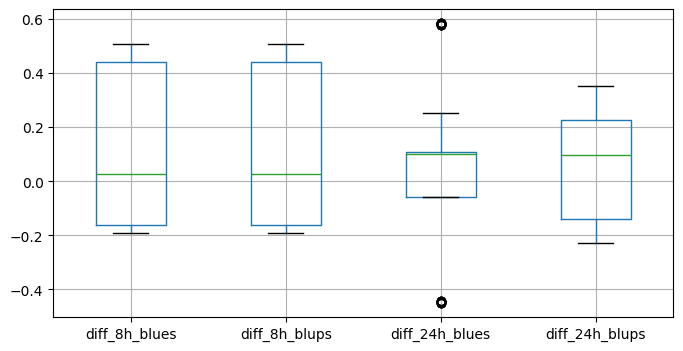

In [40]:
comparison[
    ['diff_8h_blues',
     'diff_8h_blups',
     'diff_24h_blues',
     'diff_24h_blups']
].boxplot(figsize=(8, 4))